<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   reading_score                1000 non-null   int64 
 6   writing_score                1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB
None
(1000, 7)
Numerical features : ['reading_score' 'writing_score'] 
Categorical features : ['gender' 'race_ethnicity' 'parental_level_of_education' 'lunch'
 'test_preparation_course'] 
[[0.19399858 0.39149181 1.         0.         0.         1.
  0.         0.         0.         0.         1.         0.
  0.         0.        

<Axes: xlabel='math_score', ylabel='predicted'>

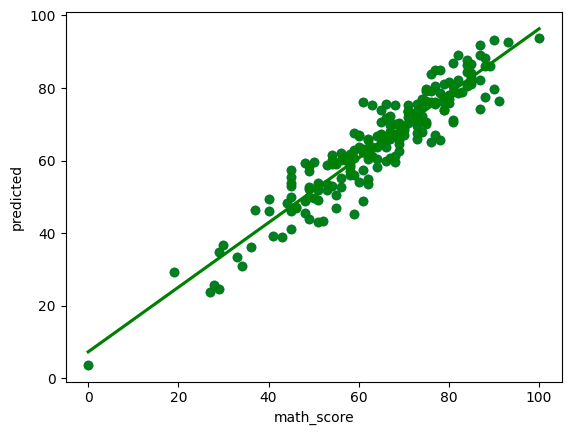

In [53]:
# import data and packages

# Standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Preprocessing related packages 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# train test split 
from sklearn.model_selection import train_test_split

# Modeling related packages
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
# model evaluation related packages
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score


# create evaluation method to give all metrics after model training 
def evaluate_model(actual_values, predicted_values)->[float,float,float,float]:
    mae = mean_absolute_error(actual_values,predicted_values)
    mse = mean_squared_error(actual_values,predicted_values)
    rmse = root_mean_squared_error(actual_values,predicted_values)
    r2score = r2_score(actual_values,predicted_values)
    return mae,mse,rmse,r2score


# import data from csv
df = pd.read_csv('data/raw.csv')

# create input , output feature x - input , y - output
x = df.drop(columns=['math_score'],axis=1)
y = df['math_score']

# separate out numerical and categorial columns from input 
print(x.info())
print(x.shape)
numerical_features = x.select_dtypes(exclude="object").columns
categorial_features = x.select_dtypes(include='object').columns

print(f"Numerical features : {numerical_features.values} ")
print(f"Categorical features : {categorial_features.values} ")

# Data Preprocessing -> Column Transformer 

# for numeric features : standard scaler -> Merge numeric columns in to one  
# for categorical features : One Hot Encoder -> to create per 
# category a new column with true false value

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

transformers = [("StandardScaler", numeric_transformer, numerical_features),
                ("OneHotEncoder", categorical_transformer, categorial_features)]

preprocessor = ColumnTransformer(transformers)
x = preprocessor.fit_transform(x)
print(x[:1])
print(x.shape)

# Train test split 
# Split dataset in to train and test datasets
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(f"Train set : {x_train.shape} and Test set : {x_test.shape} ")

# Model Training 
models_list =[]
r2_score_list = []

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

for i in range(len(list(models))):
    print("selected model :", list(models.keys())[i])
    models_list.append(list(models.keys())[i])
    selected_model = list(models.values())[i]
    # Train model
    selected_model.fit(x_train,y_train)

    # lets make predictions with trained model for train / test  (train to check overfit) 
    train_pred = selected_model.predict(x_train)
    test_pred = selected_model.predict(x_test)

    # evaluate Model 
    model_train_mae, model_train_mse, model_train_rmse , model_train_r2score = evaluate_model(y_train, train_pred)
    model_test_mae, model_test_mse, model_test_rmse , model_test_r2score = evaluate_model(y_test, test_pred)
    
    r2_score_list.append(model_test_r2score)
    # print logs 
    print("Model Performance for Training Set")
    print(" > Mean Absolute Error : {:.4f}".format(model_train_mae))
    print(" > Mean Squared Error : {:.4f}".format(model_train_mse))
    print(" > Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print(" > R2 Score : {:.4f}".format(model_train_r2score))
    print("--"*15)
    print("Model Performance for Test Set")
    print(" > Mean Absolute Error : {:.4f}".format(model_test_mae))
    print(" > Mean Squared Error : {:.4f}".format(model_test_mse))
    print(" > Root Mean Squared Error : {:.4f}".format(model_test_rmse))
    print(" > R2 Score : {:.4f}".format(model_test_r2score))
    print("*"*30)
    print("\n\n")


# Print R2 Score of each Model 
print(pd.DataFrame(list(zip(models_list,r2_score_list)),columns=['Model Name', 'R2 Score']).sort_values(by=["R2 Score"]))

# As per score we can proceed with Linear / Ridge Regression
#  predict by using Linear Regression
linear_model = LinearRegression(fit_intercept=True)
selected_lin_model = linear_model.fit(x_train,y_train) # model train
linear_y_pred = selected_lin_model.predict(x_test) # prediction
r2score = r2_score(y_test,linear_y_pred)*100
print("Accuracy of linear model is : {}".format(r2score))

# Difference between actual and predicted values - test by Linear model
pred_df = pd.DataFrame({'actual values ':y_test, 'predicted values': linear_y_pred, "Difference": y_test - linear_y_pred })
print(pred_df)

# plot test 
plt.scatter(y_test,linear_y_pred)
plt.xlabel('actual')
plt.ylabel('predicted')

# sns plot
sns.regplot(x=y_test, y = linear_y_pred, ci=None,color='Green')

